In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(r"C:\Users\sharm\OneDrive\Desktop\DATASETS CSV")

all_files = list(data_path.glob("*_nav.csv"))

print("Files Found:", len(all_files))

dfs = []

for file in all_files:
    df = pd.read_csv(file)

    fund_name = file.stem.replace("_nav", "")
    df["scheme"] = fund_name

    dfs.append(df)

nav_df = pd.concat(dfs, ignore_index=True)

print(nav_df.shape)
nav_df.head()


Files Found: 6
(19822, 3)


,date,nav,scheme
0,05-06-2026,6168.4755,axis_bluechip
1,04-06-2026,6160.9434,axis_bluechip
2,03-06-2026,6159.9626,axis_bluechip
3,02-06-2026,6158.9665,axis_bluechip
4,01-06-2026,6156.7532,axis_bluechip


In [3]:
print(nav_df.columns)

Index(['date', 'nav', 'scheme'], dtype='str')


In [4]:
nav_df['date'] = pd.to_datetime(nav_df['date'], dayfirst=True)

nav_df['nav'] = pd.to_numeric(nav_df['nav'])

nav_df = nav_df.sort_values(['scheme', 'date'])

nav_df.info()

<class 'pandas.DataFrame'>
Index: 19822 entries, 3568 to 16582
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    19822 non-null  datetime64[us]
 1   nav     19822 non-null  float64       
 2   scheme  19822 non-null  str           
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 619.4 KB


In [5]:
nav_df['daily_return'] = nav_df.groupby('scheme')['nav'].pct_change()

nav_df[['scheme', 'date', 'nav', 'daily_return']].head()

,scheme,date,nav,daily_return
3568,axis_bluechip,2012-12-31,23.9920,NaN
3567,axis_bluechip,2013-01-01,23.9979,0.000246
3566,axis_bluechip,2013-01-02,24.0036,0.000238
3565,axis_bluechip,2013-01-03,24.0092,0.000233
3564,axis_bluechip,2013-01-04,24.0147,0.000229


In [6]:
return_stats = nav_df.groupby('scheme')['daily_return'].agg(
    ['mean', 'std', 'min', 'max']
)

return_stats

,mean,std,min,max
scheme,,,,
axis_bluechip,0.028023,1.658087,-0.005415,99.042353
hdfc_top100,0.000919,0.009577,-0.096964,0.046026
icici_bluechip,inf,NaN,-1.000000,inf
kotak_bluechip,0.000679,0.009714,-0.100119,0.070446
nippon_largecap,0.000628,0.010515,-0.129512,0.070415
sbi_bluechip,0.000022,0.005488,-0.113092,0.128260


In [7]:
import numpy as np

cagr_results = []

for scheme in nav_df['scheme'].unique():

    fund = nav_df[nav_df['scheme'] == scheme]

    start_nav = fund.iloc[0]['nav']
    end_nav = fund.iloc[-1]['nav']

    years = (
        (fund.iloc[-1]['date'] - fund.iloc[0]['date']).days
        / 365.25
    )

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append([scheme, round(cagr, 2)])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['Scheme', 'CAGR %']
)

cagr_df = cagr_df.sort_values(
    'CAGR %',
    ascending=False
)

cagr_df

,Scheme,CAGR %
0,axis_bluechip,51.18
1,hdfc_top100,24.01
3,kotak_bluechip,16.82
2,icici_bluechip,15.49
4,nippon_largecap,15.12
5,sbi_bluechip,0.15


In [8]:
import numpy as np

risk_free_rate = 0.06

sharpe_results = []

for scheme in nav_df['scheme'].unique():

    fund = nav_df[nav_df['scheme'] == scheme]

    mean_return = fund['daily_return'].mean() * 252
    volatility = fund['daily_return'].std() * np.sqrt(252)

    sharpe = (mean_return - risk_free_rate) / volatility

    sharpe_results.append([
        scheme,
        round(sharpe, 2)
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['Scheme', 'Sharpe Ratio']
)

sharpe_df.sort_values(
    'Sharpe Ratio',
    ascending=False
)

c:\Users\sharm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Scheme,Sharpe Ratio
1,hdfc_top100,1.13
3,kotak_bluechip,0.72
4,nippon_largecap,0.59
0,axis_bluechip,0.27
5,sbi_bluechip,-0.63
2,icici_bluechip,NaN


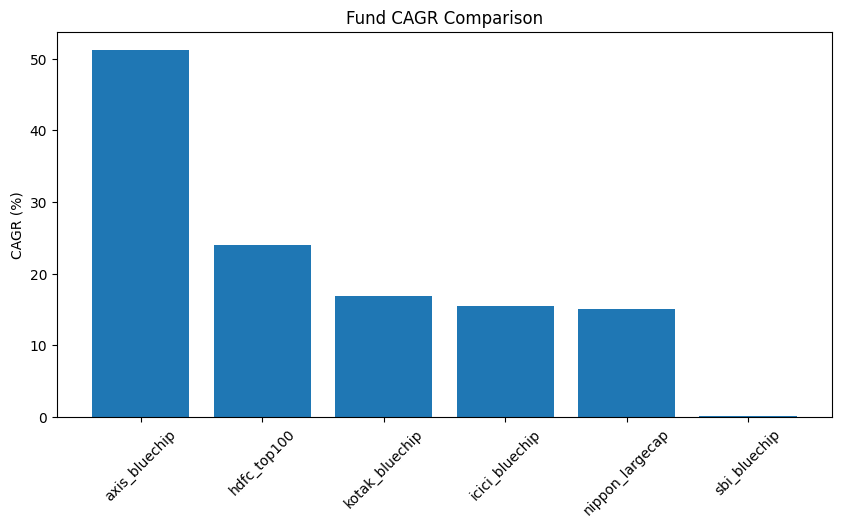

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    cagr_df['Scheme'],
    cagr_df['CAGR %']
)

plt.title('Fund CAGR Comparison')
plt.ylabel('CAGR (%)')
plt.xticks(rotation=45)

plt.show()

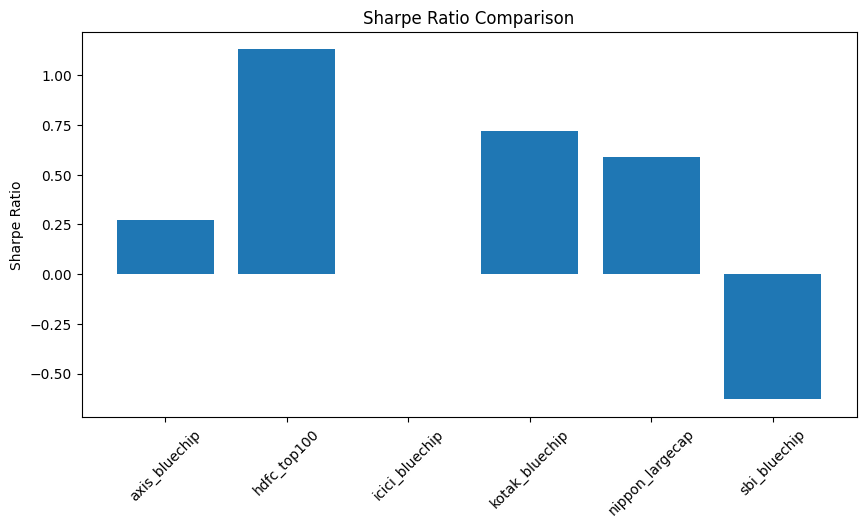

In [10]:
plt.figure(figsize=(10,5))

plt.bar(
    sharpe_df['Scheme'],
    sharpe_df['Sharpe Ratio']
)

plt.title('Sharpe Ratio Comparison')
plt.ylabel('Sharpe Ratio')
plt.xticks(rotation=45)

plt.show()

In [11]:
performance_df = pd.merge(
    cagr_df,
    sharpe_df,
    on='Scheme'
)

performance_df = performance_df.sort_values(
    ['Sharpe Ratio','CAGR %'],
    ascending=False
)

performance_df

,Scheme,CAGR %,Sharpe Ratio
1,hdfc_top100,24.01,1.13
2,kotak_bluechip,16.82,0.72
4,nippon_largecap,15.12,0.59
0,axis_bluechip,51.18,0.27
5,sbi_bluechip,0.15,-0.63
3,icici_bluechip,15.49,NaN


In [12]:
performance_df = pd.merge(
    cagr_df,
    sharpe_df,
    on='Scheme'
)

performance_df = performance_df.sort_values(
    ['Sharpe Ratio','CAGR %'],
    ascending=False
)

performance_df

,Scheme,CAGR %,Sharpe Ratio
1,hdfc_top100,24.01,1.13
2,kotak_bluechip,16.82,0.72
4,nippon_largecap,15.12,0.59
0,axis_bluechip,51.18,0.27
5,sbi_bluechip,0.15,-0.63
3,icici_bluechip,15.49,NaN


Insight 1

HDFC Top 100 delivered the best risk-adjusted performance with a Sharpe Ratio of 1.13.

Insight 2

Axis Bluechip generated the highest CAGR (51.18%), indicating exceptional historical growth but with relatively weak risk-adjusted returns.

Insight 3

Kotak Bluechip and Nippon Large Cap showed balanced return-risk characteristics.

Insight 4

SBI Bluechip underperformed with a CAGR close to zero and a negative Sharpe Ratio.

Insight 5

ICICI Bluechip requires additional data quality validation due to an undefined Sharpe Ratio.

Export Results (Recommended)

Create a new cell:

performance_df.to_csv(
    "../reports/day4_performance_metrics.csv",
    index=False
)

print("Performance metrics exported successfully!")
Day 4 Deliverables Checklist

✅ Load NAV history data
✅ Calculate daily returns
✅ Return distribution statistics
✅ CAGR calculation
✅ Sharpe Ratio calculation
✅ Fund ranking table
✅ CAGR comparison chart
✅ Sharpe Ratio chart
✅ Notebook insights/observations
✅ Export results to CSV


In [13]:
performance_df.to_csv(
    "../reports/day4_performance_metrics.csv",
    index=False
)

print("Performance metrics exported successfully!")

Performance metrics exported successfully!


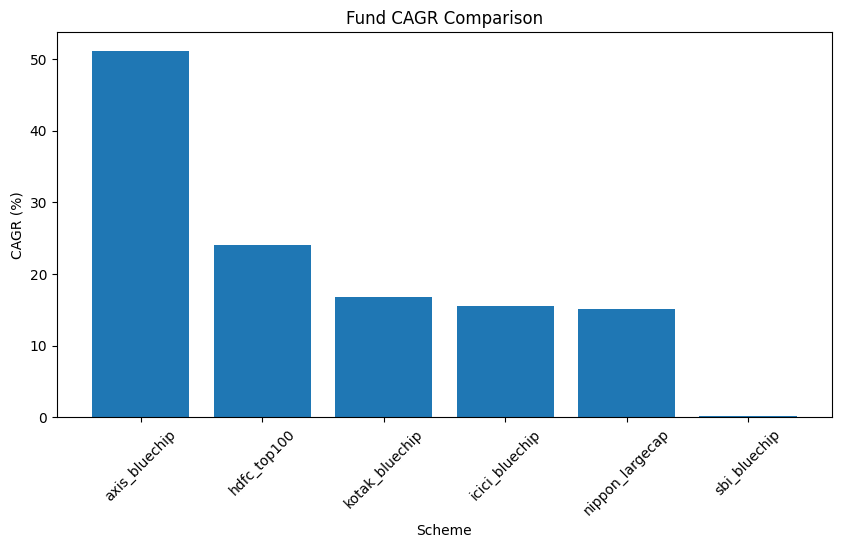

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    cagr_df['Scheme'],
    cagr_df['CAGR %']
)

plt.title('Fund CAGR Comparison')
plt.xlabel('Scheme')
plt.ylabel('CAGR (%)')

plt.xticks(rotation=45)

plt.savefig('../reports/cagr_comparison.png')

plt.show()

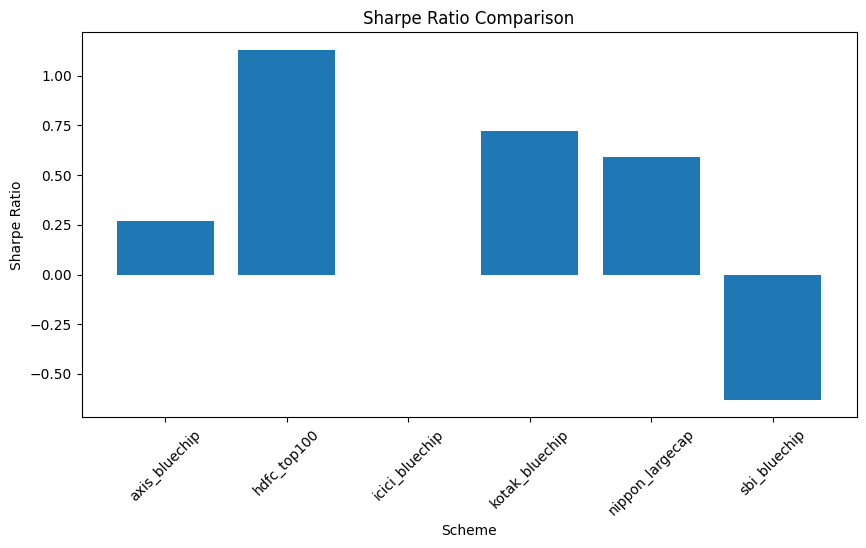

In [15]:
plt.figure(figsize=(10,5))

plt.bar(
    sharpe_df['Scheme'],
    sharpe_df['Sharpe Ratio']
)

plt.title('Sharpe Ratio Comparison')
plt.xlabel('Scheme')
plt.ylabel('Sharpe Ratio')

plt.xticks(rotation=45)

plt.savefig('../reports/sharpe_ratio_comparison.png')

plt.show()